# Datentransformation: Modelle und Ansätze im Vergleich

In [1]:
%matplotlib inline
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from reporting import compare

runs, direct = compare.load_all(seed=1)
g  = compare.codegen_by_strategy(runs)  # (Aufgabe,Modell,Strategie) -> abgegl. Genauigkeit
dm = compare.direct_matrix(direct)      # Direkt-Lauf je (Aufgabe,Modell)
bl = compare.baseline_series(runs)      # regelbasierte Baseline je Aufgabe
print(f"Code-Gen-Läufe: {len(runs)} | Direkt-Läufe: {len(direct)}")
print(f"Grafiken werden zusätzlich als PNG gespeichert unter: {compare.FIG_DIR}")

Code-Gen-Läufe: 441 | Direkt-Läufe: 36
Grafiken werden zusätzlich als PNG gespeichert unter: C:\Users\geige\Desktop\DHBW\Bachelorarbeit\project\figures


Dieses Notebook wertet die Kategorie **Datentransformation** aus. Für jeden der drei
Schwierigkeitsgrade wird die Ergebnisqualität der vier Modelle in **beiden
Ausführungsmodi** gegenübergestellt:

- **Code-Generierung** – das Modell erzeugt pandas-Code; je Modell wird **ein Balken
  pro klassischer Prompt-Strategie** gezeigt (Zero-Shot, Few-Shot, Chain-of-Thought;
  Mittel über drei Wiederholungen). So werden Strategie-Unterschiede unmittelbar
  sichtbar. Die schema-angereicherte Variante wird als separater Robustheits-Befund
  behandelt (sie verleitet zu abstürzenden Typkonvertierungen) und hier nicht gezeigt.
- **Direkt-Verarbeitung** – das Modell liefert die Ergebnistabelle unmittelbar
  (ein orangefarbener Balken je Modell),
- **regelbasierte Baseline** – als gestrichelte Referenzlinie.

Als Kennzahl dient die **abgeglichene Genauigkeit**: Bei stimmendem Schema wird der
Anteil korrekt reproduzierter Werte zeilenweise gegen das Soll gemessen, statt bei
leicht abweichender Zeilenzahl hart auf 0 zu fallen (519 von 520 korrekten Zeilen
ergeben so ~99 % statt 0 %).

> Die Baseline-Linie ist der entscheidende Bezugspunkt: Wo auch das regelbasierte
> Verfahren keine 100 % erreicht (etwa bei den semantischen Aufgaben), ist eine
> Genauigkeit von 100 % kein sinnvoller Maßstab – dann zählt der Abstand zur Baseline.

Alle Grafiken werden automatisch als PNG unter `project/figures/` abgelegt und lassen
sich direkt in die Projektarbeit übernehmen.

## Einfach: `transform_easy_type_conversion`

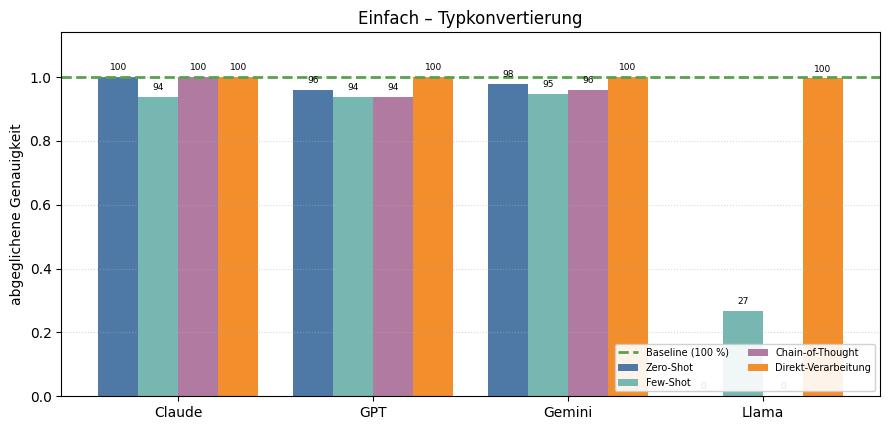

,Zero-Shot,Few-Shot,Chain-of-Thought,Direkt
Claude,100.0,93.8,100.0,100.0
GPT,95.9,93.8,93.8,100.0
Gemini,97.9,94.8,95.9,100.0
Llama,0.0,26.7,0.0,99.6
Baseline (Referenz),100.0,100.0,100.0,NaN


In [2]:
task = "transform_easy_type_conversion"
fig, ax = plt.subplots(figsize=(9, 4.4))
compare.compare_task_strategies(task, g, dm, bl, ax=ax, save=False)
fig.tight_layout(); compare.save_fig(fig, f"strat_{task}"); plt.show()
display(compare.strategy_table(task, g, dm, bl))

## Mittel: `transform_medium_derived_columns`

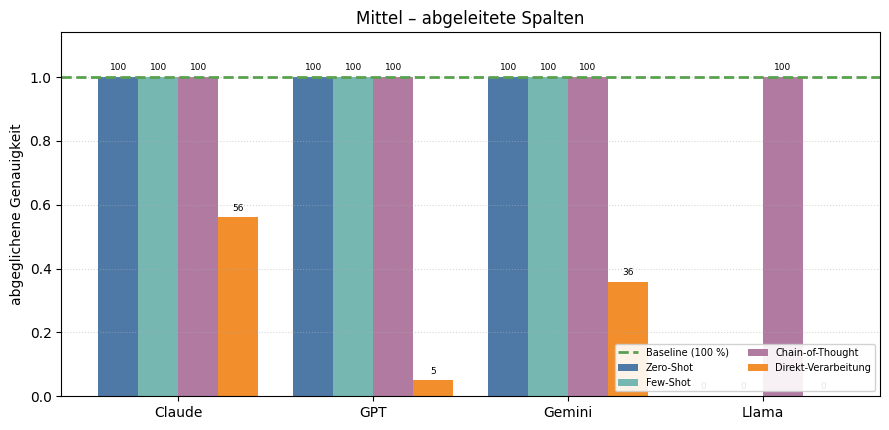

,Zero-Shot,Few-Shot,Chain-of-Thought,Direkt
Claude,100.0,100.0,100.0,56.0
GPT,100.0,100.0,100.0,5.0
Gemini,100.0,100.0,100.0,35.9
Llama,0.0,0.0,100.0,0.0
Baseline (Referenz),100.0,100.0,100.0,NaN


In [3]:
task = "transform_medium_derived_columns"
fig, ax = plt.subplots(figsize=(9, 4.4))
compare.compare_task_strategies(task, g, dm, bl, ax=ax, save=False)
fig.tight_layout(); compare.save_fig(fig, f"strat_{task}"); plt.show()
display(compare.strategy_table(task, g, dm, bl))

## Schwer: `transform_hard_join_and_aggregate`

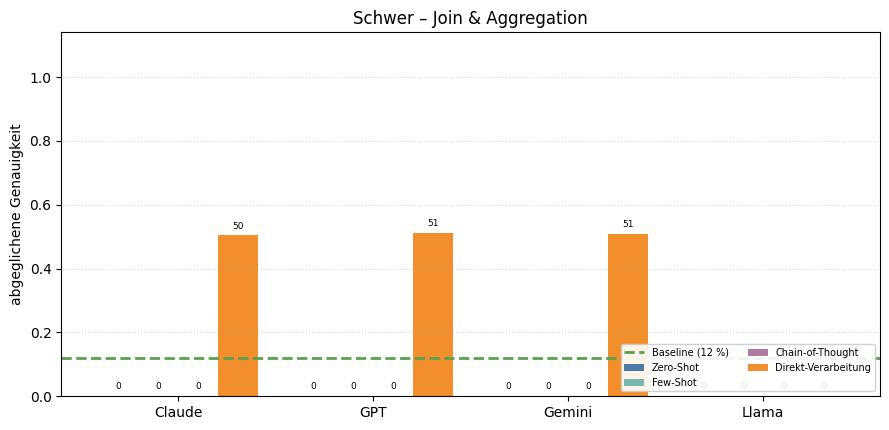

,Zero-Shot,Few-Shot,Chain-of-Thought,Direkt
Claude,0.0,0.0,0.0,50.4
GPT,0.2,0.0,0.0,51.2
Gemini,0.0,0.0,0.0,50.8
Llama,0.0,0.0,0.0,0.0
Baseline (Referenz),12.1,12.1,12.1,NaN


In [4]:
task = "transform_hard_join_and_aggregate"
fig, ax = plt.subplots(figsize=(9, 4.4))
compare.compare_task_strategies(task, g, dm, bl, ax=ax, save=False)
fig.tight_layout(); compare.save_fig(fig, f"strat_{task}"); plt.show()
display(compare.strategy_table(task, g, dm, bl))

## Alle drei Schwierigkeitsgrade in einer Grafik

Kombinierte Abbildung für die Projektarbeit (wird als `figures/kategorie_transformation_strategien.png` gespeichert).

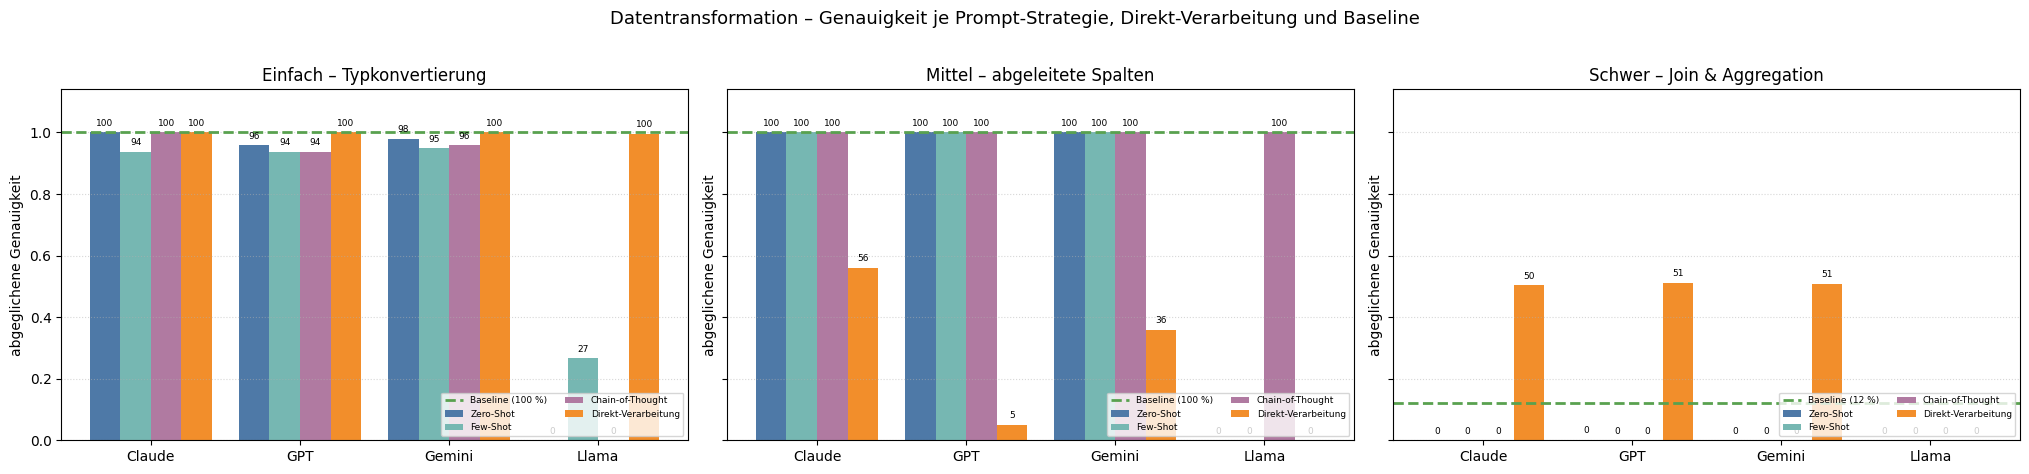

In [5]:
compare.compare_category_strategies("transformation", runs, direct); plt.show()